In [139]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [140]:
# !cp -r /content/drive/MyDrive/DL_Project/datasets/ffpp_cropped_faces /content/

In [141]:
# !cp -r /content/drive/MyDrive/DL_Project/datasets/celebv2_cropped_faces /content/

Dependencies and Imports...

In [142]:
!pip install -q timm torchmetrics

In [143]:
import timm

import os
import random
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Reproducibility...

In [144]:
seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [145]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


Configurations...

In [146]:
[x for x in timm.list_models() if 'vit_base' in x]

['convit_base',
 'crossvit_base_240',
 'davit_base',
 'davit_base_fl',
 'flexivit_base',
 'gcvit_base',
 'maxvit_base_tf_224',
 'maxvit_base_tf_384',
 'maxvit_base_tf_512',
 'naflexvit_base_patch16_gap',
 'naflexvit_base_patch16_map',
 'naflexvit_base_patch16_par_gap',
 'naflexvit_base_patch16_parfac_gap',
 'naflexvit_base_patch16_siglip',
 'nextvit_base',
 'samvit_base_patch16',
 'samvit_base_patch16_224',
 'vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_dinov3',
 'vit_base_patch16_dinov3_qkvb',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_r

In [147]:
model_name = 'vit_base_patch16_224'

image_size = 224
batch_size = 32

learning_rate = 5e-5
weight_decay = 1e-4

maximum_epochs = 20
patience = 5

Dataset Path...

In [148]:
# root = '/content/drive/MyDrive/DL_Project/datasets'

# ffpp_root = os.path.join(root, 'ffpp_cropped_faces')

# celeb_root = os.path.join(root, 'celebv2_cropped_faces')

ffpp_root = '/content/ffpp_cropped_faces'

celeb_root = '/content/celebv2_cropped_faces'

Dataset Staistics...

In [149]:
def count_images(folder):

    real = len(os.listdir(os.path.join(folder,'real')))
    fake = len(os.listdir(os.path.join(folder,'fake')))

    return real, fake

In [150]:
for split in ['train','val','test']:
    real,fake = count_images(os.path.join(ffpp_root, split))

    print('\n', split,':', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


 train : real = 7500 | fake = 6869 | total = 14369

 val : real = 1250 | fake = 1130 | total = 2380

 test : real = 1250 | fake = 1138 | total = 2388


In [151]:
real,fake = count_images(celeb_root)

print('\nceleb-df :', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


celeb-df : real = 2999 | fake = 2991 | total = 5990


Dataset Class...

In [152]:
class DeepfakeDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform
        self.samples = []

        real_dir = os.path.join(root_dir, 'real')
        fake_dir = os.path.join(root_dir, 'fake')

        for img in os.listdir(real_dir):
            self.samples.append((os.path.join(real_dir,img), 0))

        for img in os.listdir(fake_dir):
            self.samples.append((os.path.join(fake_dir,img), 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self,idx):

        path,label = self.samples[idx]
        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label,dtype=torch.float32)

Transforms...

In [153]:
imagenet_mean = [0.485,0.456,0.406]
imagenet_std = [0.229,0.224,0.225]

In [154]:
train_transform = transforms.Compose([transforms.Resize((image_size,image_size)),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1),
                                      transforms.ToTensor(),
                                      transforms.Normalize(imagenet_mean, imagenet_std)])

In [155]:
test_transform = transforms.Compose([transforms.Resize((image_size,image_size)),
                                     transforms.ToTensor(),
                                     transforms.Normalize(imagenet_mean, imagenet_std)])

Dataloaders...

In [156]:
train_ds = DeepfakeDataset(os.path.join(ffpp_root, 'train'), train_transform)

val_ds = DeepfakeDataset(os.path.join(ffpp_root, 'val'), test_transform)

test_ds = DeepfakeDataset(os.path.join(ffpp_root, 'test'), test_transform)

celeb_ds = DeepfakeDataset(celeb_root, test_transform)

In [157]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

celeb_loader = DataLoader(celeb_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

In [158]:
print('\nlength of train ffpp :', len(train_ds))
print('\nlength of val ffpp :', len(val_ds))
print('\nlength of test ffpp :', len(test_ds))
print('\nlength of celeb :', len(celeb_ds))


length of train ffpp : 14369

length of val ffpp : 2380

length of test ffpp : 2388

length of celeb : 5990


In [159]:
next(iter(train_loader))[0].shape

torch.Size([32, 3, 224, 224])

Model...

In [160]:
model = timm.create_model(model_name, pretrained=True, num_classes=1)

model = model.to(device)

In [161]:
print(model.get_classifier())

Linear(in_features=768, out_features=1, bias=True)


In [162]:
total_parameters = sum(p.numel() for p in model.parameters())

print(f'\nparameters: {total_parameters:,}')


parameters: 85,799,425


Loss / Optimizer ...

In [163]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [164]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

AMP...

In [165]:
scaler = torch.amp.GradScaler('cuda')

Evaluation Function...

In [166]:
@torch.no_grad()

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []

    for images, labels in tqdm(loader, leave=False):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze(1)
        labels = labels.float().view_as(outputs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    auc = roc_auc_score(all_labels, all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss': epoch_loss,
        'auc': auc,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
        'preds': np.array(all_preds)
    }

Training Loop...

In [167]:
history = {'train_loss': [], 'val_loss': [], 'val_auc': [],
           'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []}

best_auc = 0.0
patience_counter = 0

save_dir = '/content/drive/MyDrive/DL_Project/checkpoints'
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir,'best_vit_b16.pth')

In [168]:
for epoch in range(maximum_epochs):

    print(f'\nepoch [{epoch+1}/{maximum_epochs}]')

    # training...

    model.train()

    running_loss = 0.0

    pbar = tqdm(train_loader)

    for images, labels in pbar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):

            outputs = model(images).squeeze(1)
            labels = labels.view_as(outputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        pbar.set_postfix(loss=f'{loss.item():.3f}')

    train_loss = running_loss/len(train_loader.dataset)

    # validation..

    val_metrics = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_auc = val_metrics['auc']

    val_acc = val_metrics['accuracy']
    val_precision = val_metrics['precision']
    val_recall = val_metrics['recall']
    val_f1 = val_metrics['f1']

    scheduler.step(val_auc)

    history['train_loss'].append(train_loss)

    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)

    print(f'\ntrain loss  : {train_loss:.4f}')

    print(f'\nval loss  : {val_loss:.4f}')
    print(f'\nval auc  : {val_auc:.4f}')

    print(f'\nval accuracy  : {val_acc:.4f}')
    print(f'val precision  : {val_precision:.4f}')
    print(f'val recall  : {val_recall:.4f}')
    print(f'val f1  : {val_f1:.4f}')

    # early stopping..

    if val_auc > best_auc:
        best_auc = val_auc
        patience_counter = 0

        torch.save({'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_auc': best_auc},best_model_path)

        print(f'\nbest model saved (auc={best_auc:.4f})')

    else:
        patience_counter += 1
        print(f'\nno improvement ({patience_counter}/{patience})')

    if patience_counter >= patience:
        print('\nearly stopping triggered...')

        break


epoch [1/20]


  0%|          | 0/450 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


train loss  : 0.6005

val loss  : 1.0844

val auc  : 0.7591

val accuracy  : 0.6059
val precision  : 0.5513
val recall  : 0.9124
val f1  : 0.6873

best model saved (auc=0.7591)

epoch [2/20]


  0%|          | 0/450 [00:00<?, ?it/s]

...

  0%|          | 0/75 [00:00<?, ?it/s]


train loss  : 0.0457

val loss  : 1.0333

val auc  : 0.8965

val accuracy  : 0.8168
val precision  : 0.7956
val recall  : 0.8265
val f1  : 0.8108

no improvement (4/5)

epoch [11/20]


  0%|          | 0/450 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


train loss  : 0.0336

val loss  : 1.3652

val auc  : 0.8904

val accuracy  : 0.8084
val precision  : 0.7827
val recall  : 0.8257
val f1  : 0.8036

no improvement (5/5)

early stopping triggered...


In [169]:
history_df = pd.DataFrame(history)

results_dir = '/content/drive/MyDrive/DL_Project/results/vit_baseline/'

os.makedirs(results_dir, exist_ok=True)
history_df.to_csv(os.path.join(results_dir, 'vit_b16_training_history.csv'), index=False)

print('training history saved...')

training history saved...


Load Model Checkpoint...

In [170]:
checkpoint_path = '/content/drive/MyDrive/DL_Project/checkpoints/best_vit_b16.pth'

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print(f'best epoch : {checkpoint['epoch']}')
print(f'best auc   : {checkpoint['best_auc']:.4f}')

best epoch : 6
best auc   : 0.9048


In [171]:
print(len(test_loader.dataset))
print(len(celeb_loader.dataset))

2388
5990


Learning Curves...

In [172]:
history_df = pd.read_csv('/content/drive/MyDrive/DL_Project/results/vit_baseline/vit_b16_training_history.csv')

In [173]:
history_df['epoch'] = range(1,len(history_df) + 1)
history_df.head()

,train_loss,val_loss,val_auc,val_acc,val_precision,val_recall,val_f1,epoch
0,0.600493,1.084371,0.759130,0.605882,0.551337,0.912389,0.687333,1
1,0.369669,0.443219,0.880583,0.789916,0.765599,0.803540,0.784111,2
2,0.248443,0.439648,0.892361,0.823529,0.838095,0.778761,0.807339,3
3,0.188701,0.548373,0.898585,0.810084,0.767350,0.861062,0.811510,4
4,0.154985,0.703692,0.872952,0.794958,0.828893,0.715929,0.768281,5


In [174]:
output_dir = '/content/drive/MyDrive/DL_Project/results/vit_baseline/'
os.makedirs(output_dir, exist_ok=True)

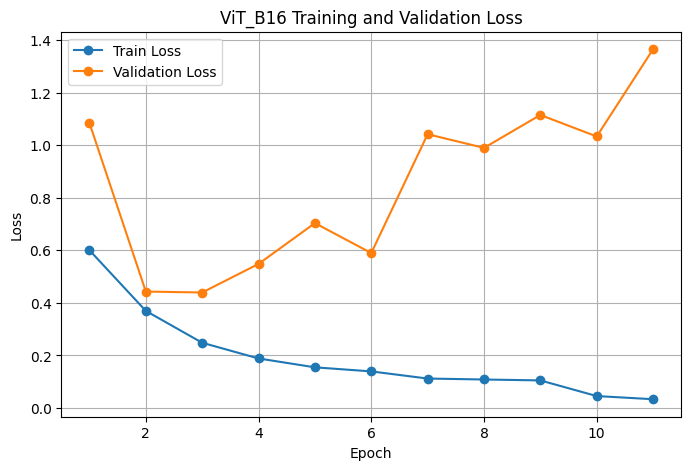

In [175]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')

plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ViT_B16 Training and Validation Loss')

plt.legend()
plt.grid(True)

save_path = os.path.join(output_dir, 'vit_b16_loss_plot.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

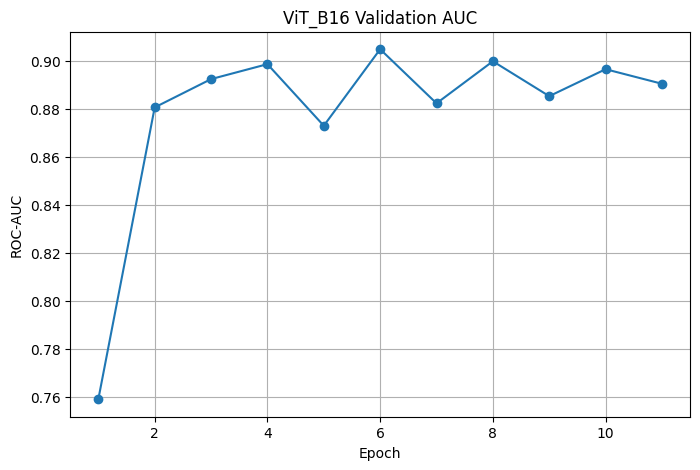

In [176]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['val_auc'], marker='o')

plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.title('ViT_B16 Validation AUC')

plt.grid(True)

save_path = os.path.join(output_dir, 'vit_b16_auc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

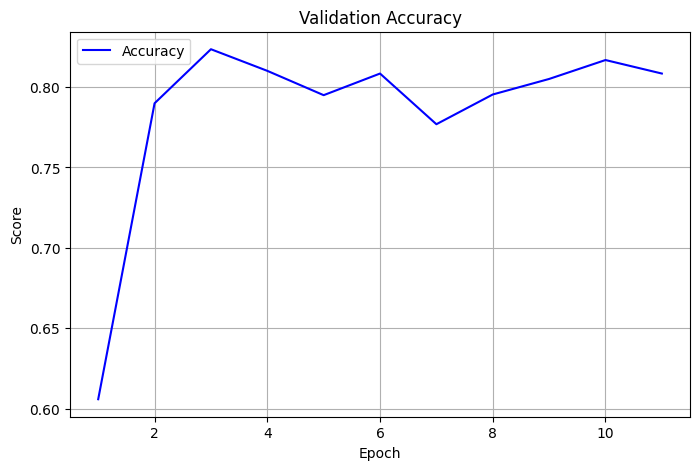

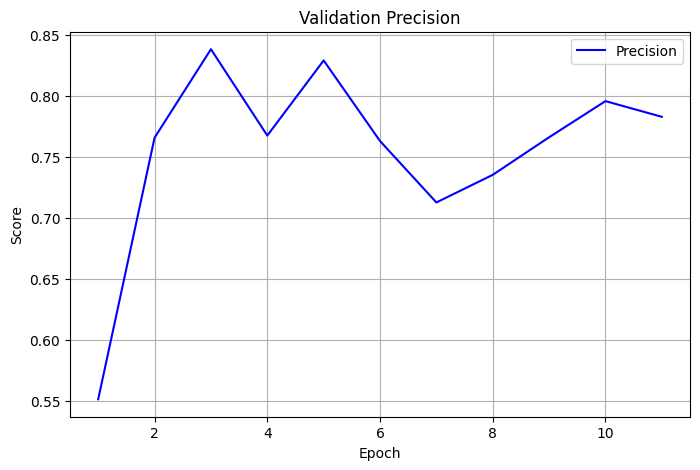

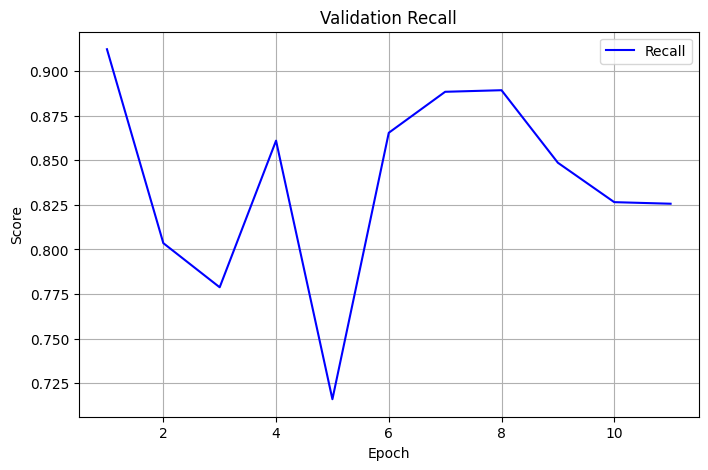

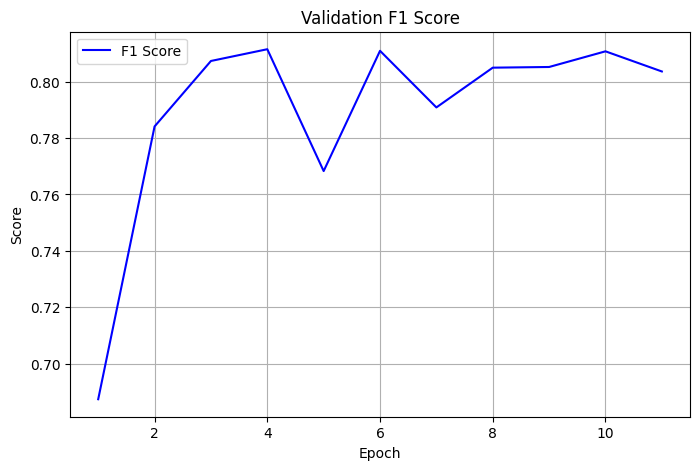

In [177]:
metrics = ['val_acc', 'val_precision', 'val_recall', 'val_f1']
display_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric, name in zip(metrics, display_names):
    plt.figure(figsize=(8,5))

    plt.plot(history_df['epoch'], history_df[metric], label=name, color='blue')

    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title(f'Validation {name}')

    plt.legend()
    plt.grid(True)

    file_name = f'vit_b16_{metric}.pdf'
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, bbox_inches='tight')

    plt.show()

FF++ Evaluation...

In [178]:
ffpp_metrics = evaluate(model, test_loader, criterion)

print('\nfaceforensics++ test results')

print(f'AUC  : {ffpp_metrics['auc']:.4f}')
print(f'Accuracy  : {ffpp_metrics['accuracy']:.4f}')
print(f'Precision  : {ffpp_metrics['precision']:.4f}')
print(f'Recall  : {ffpp_metrics['recall']:.4f}')
print(f'F1  : {ffpp_metrics['f1']:.4f}')

  0%|          | 0/75 [00:00<?, ?it/s]


faceforensics++ test results
AUC  : 0.8839
Accuracy  : 0.7726
Precision  : 0.7142
Recall  : 0.8717
F1  : 0.7851


FF++ ROC Curve...

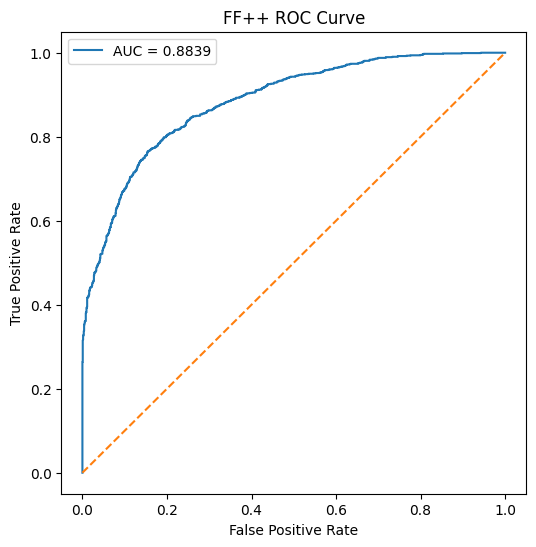

In [179]:
fpr, tpr, _ = roc_curve(ffpp_metrics['labels'], ffpp_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {ffpp_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('FF++ ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'vit_b16_ffpp_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

FF++ Confusion Matrix...

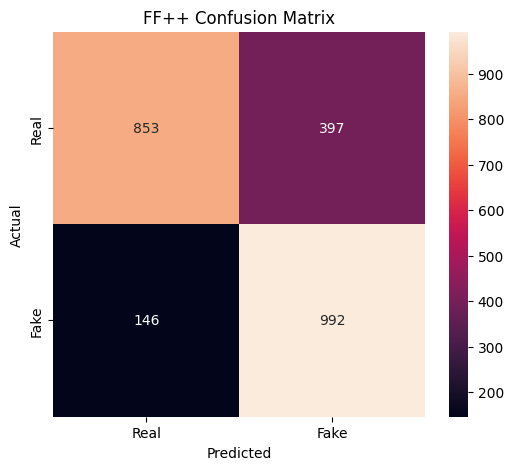

In [180]:
import seaborn as sns

cm = confusion_matrix(ffpp_metrics['labels'], ffpp_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('FF++ Confusion Matrix')

save_path = os.path.join(output_dir, 'vit_b16_ffpp_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Evaluation...

In [181]:
celeb_metrics = evaluate(model, celeb_loader, criterion)

print('\ncelebv2 evaluation results')

print(f'AUC  : {celeb_metrics['auc']:.4f}')
print(f'Accuracy  : {celeb_metrics['accuracy']:.4f}')
print(f'Precision  : {celeb_metrics['precision']:.4f}')
print(f'Recall  : {celeb_metrics['recall']:.4f}')
print(f'F1  : {celeb_metrics['f1']:.4f}')

  0%|          | 0/188 [00:00<?, ?it/s]


celebv2 evaluation results
AUC  : 0.7765
Accuracy  : 0.6105
Precision  : 0.5639
Recall  : 0.9709
F1  : 0.7134


CelebV2 ROC Curve...

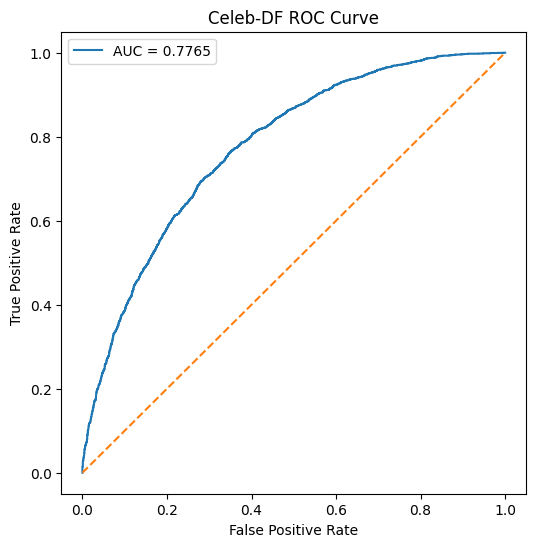

In [182]:
fpr, tpr, _ = roc_curve(celeb_metrics['labels'], celeb_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {celeb_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Celeb-DF ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'vit_b16_celebv2_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Confusion Matrix...

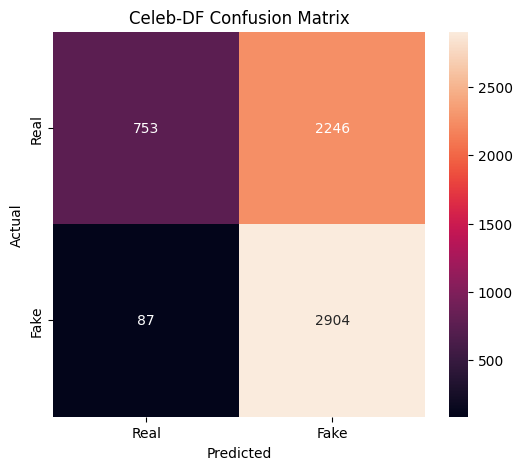

In [183]:
cm = confusion_matrix(celeb_metrics['labels'], celeb_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Celeb-DF Confusion Matrix')

save_path = os.path.join(output_dir, 'vit_b16_celebv2_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

Generalization Gap...

In [184]:
generalization_gap = (ffpp_metrics['auc'] - celeb_metrics['auc'])

print('\ngeneralization gap')

print(f'FF++ AUC  : {ffpp_metrics['auc']:.4f}')

print(f'CelebDF AUC  : {celeb_metrics['auc']:.4f}')

print(f'Gap  : {generalization_gap:.4f}')


generalization gap
FF++ AUC  : 0.8839
CelebDF AUC  : 0.7765
Gap  : 0.1074


Final Results Table...

In [185]:
results_df = pd.DataFrame([

    {
        'Dataset':'FF++ Test',

        'AUC':ffpp_metrics['auc'],
        'Accuracy':ffpp_metrics['accuracy'],
        'Precision':ffpp_metrics['precision'],
        'Recall':ffpp_metrics['recall'],
        'F1':ffpp_metrics['f1']
    },

    {
        'Dataset':'CelebDF',

        'AUC':celeb_metrics['auc'],
        'Accuracy':celeb_metrics['accuracy'],
        'Precision':celeb_metrics['precision'],
        'Recall':celeb_metrics['recall'],
        'F1':celeb_metrics['f1']
    }
])

results_df

,Dataset,AUC,Accuracy,Precision,Recall,F1
0,FF++ Test,0.883898,0.772613,0.714183,0.871705,0.785121
1,CelebDF,0.776479,0.610518,0.563883,0.970913,0.713426


In [186]:
results_dir = '/content/drive/MyDrive/DL_Project/results/vit_baseline/'

os.makedirs(results_dir, exist_ok=True)

results_df.to_csv(os.path.join(results_dir, 'vit_b16_results.csv'), index=False)

print('results saved.')

results saved.
